Import some libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Drive mount to colab notebook
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Data read for pandas dataframe
df = pd.read_csv("/content/drive/MyDrive/Datasets/Stock_Market_Analysis_dataset.csv")
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


Data Cleaning..

In [4]:
# Drop null and duplicate values
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)

In [5]:
# count null values in each column
df.isnull().sum()

,0
Ticker,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [6]:
# count duplicate values in each column
df.duplicated().sum()

np.int64(0)

In [7]:
# Discribe data df
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


In [8]:
# Size of data
df.shape

(248, 8)

In [9]:
# Check data type of each column
df.dtypes

,0
Ticker,object
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,int64


In [10]:
# Make a copy named df_final
df_final = df.copy()
df_final

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000
...,...,...,...,...,...,...,...,...
243,GOOG,2023-05-01,107.720001,108.680000,107.500000,107.709999,107.709999,20926300
244,GOOG,2023-05-02,107.660004,107.730003,104.500000,105.980003,105.980003,20343100
245,GOOG,2023-05-03,106.220001,108.129997,105.620003,106.120003,106.120003,17116300
246,GOOG,2023-05-04,106.160004,106.300003,104.699997,105.209999,105.209999,19780600


Exploratory Data Analysis (EDA)

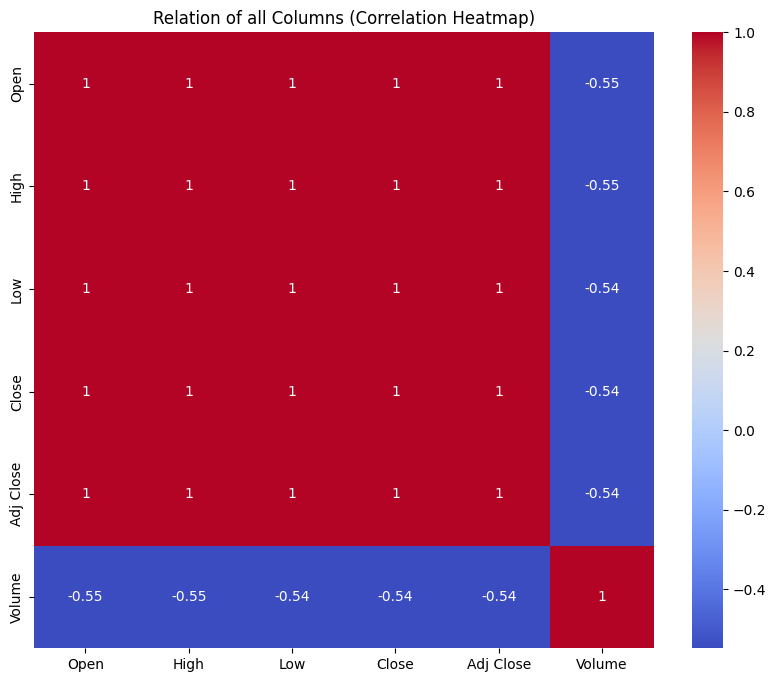

In [11]:
# check relation of all numeric cloumns
plt.figure(figsize=(10, 8))

sns.heatmap(df_final.corr(numeric_only = True), annot=True, cmap="coolwarm")
plt.title("Relation of all Columns (Correlation Heatmap)")
plt.show()

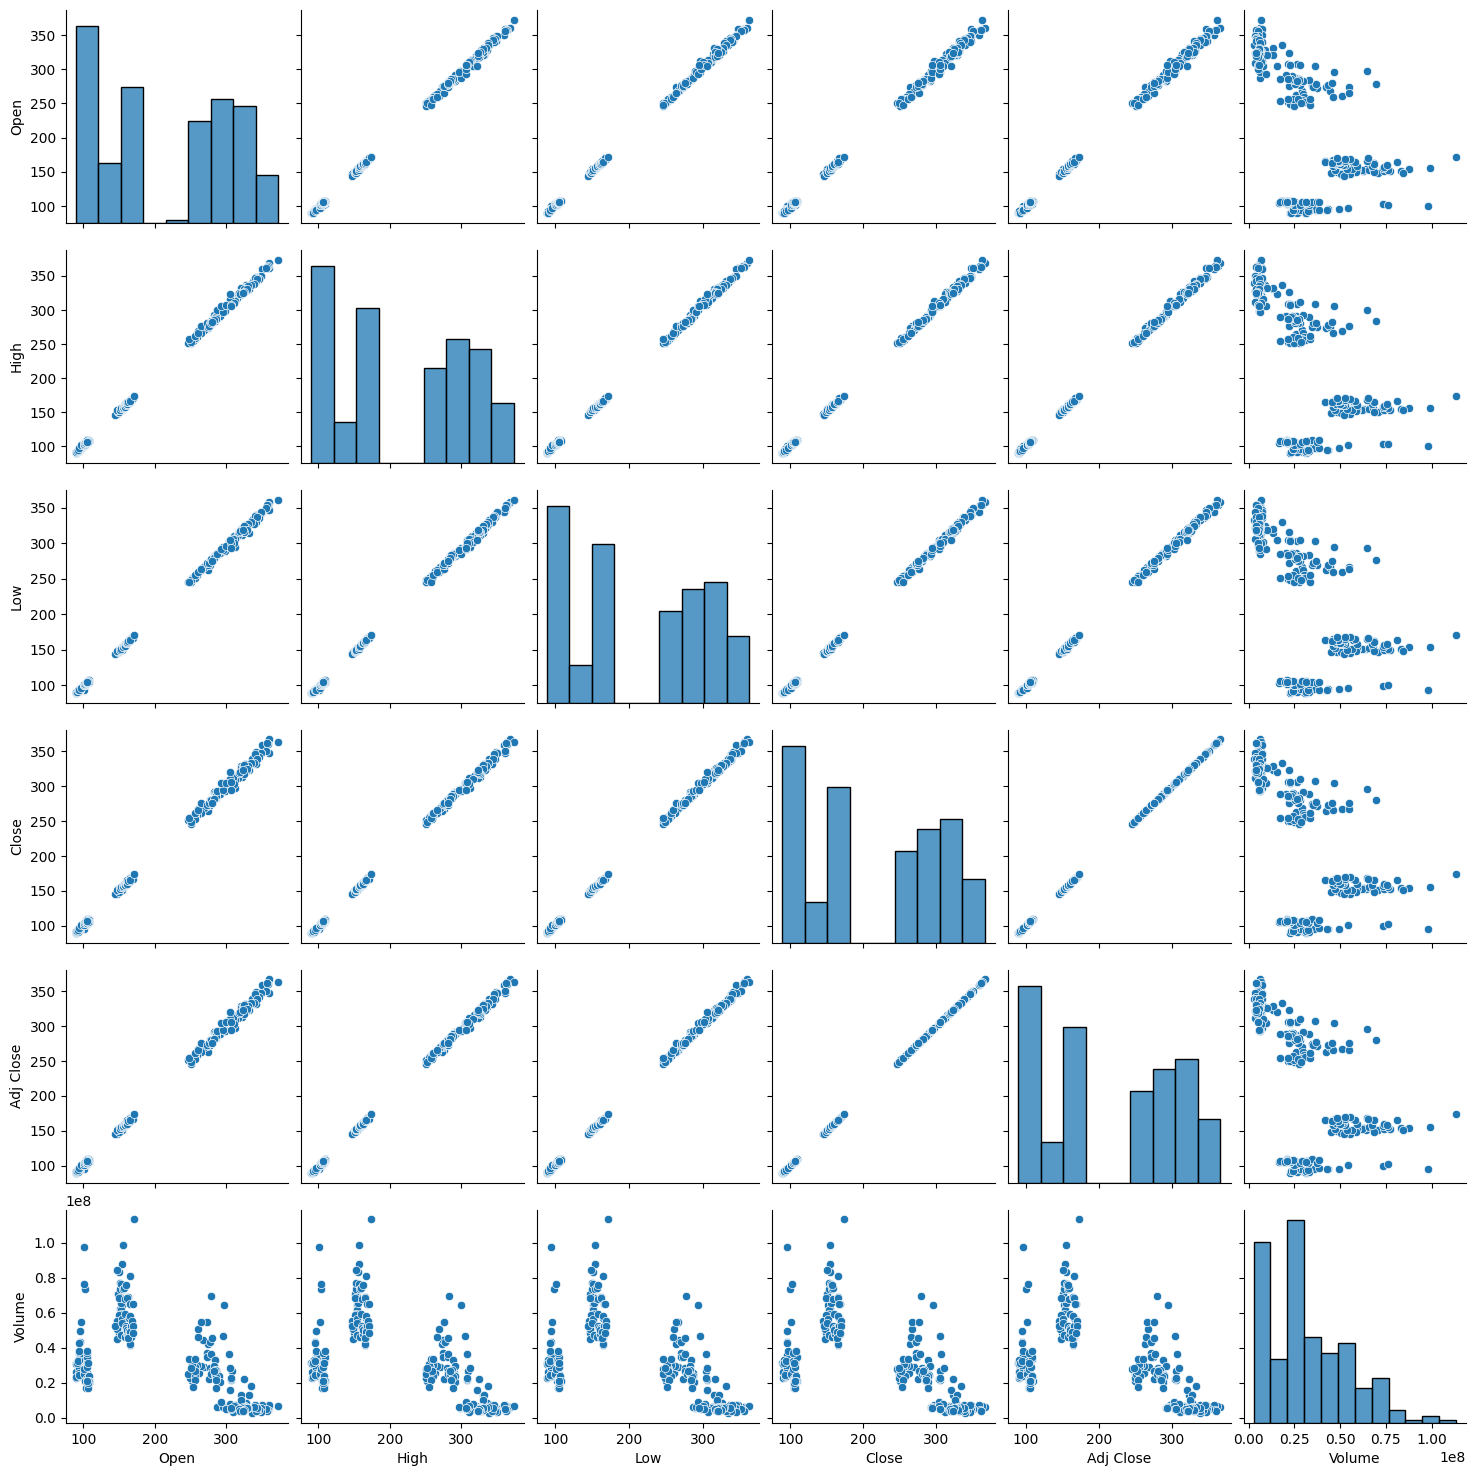

In [12]:
sns.pairplot(df_final)
plt.show()

Find outliers from Open column.

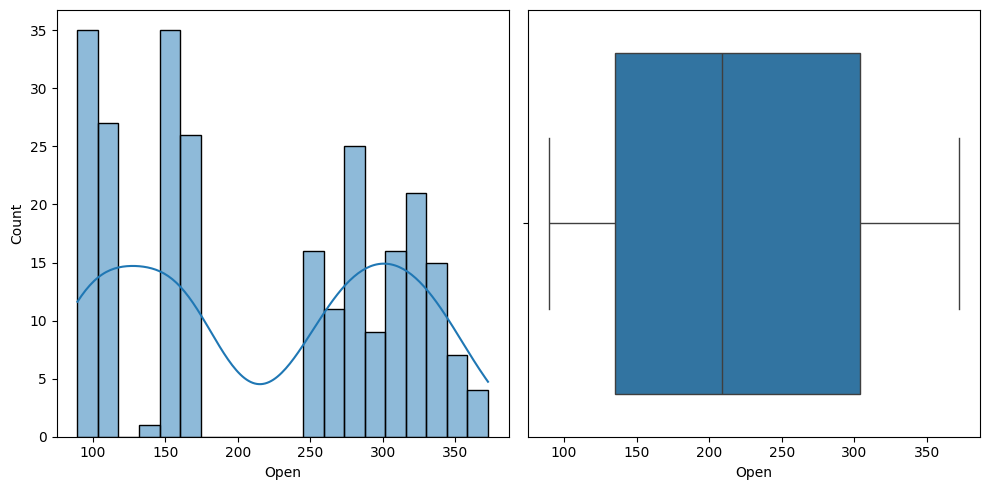

In [ ]:
# create a hist and box plot to see outliers
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(df_final["Open"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["Open"])

plt.tight_layout()
plt.show()

Find outliers from High column.

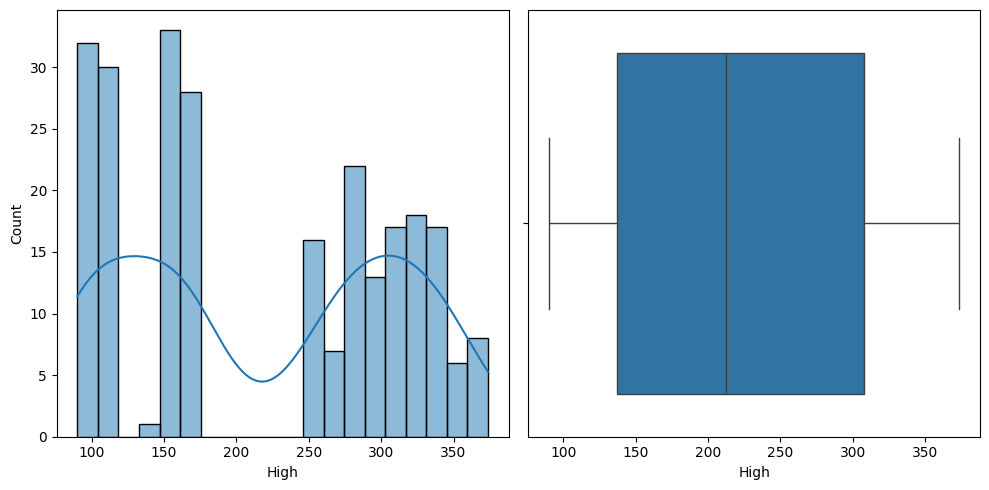

In [ ]:
# create a hist and box plot to see outliers
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(df_final["High"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["High"])

plt.tight_layout()
plt.show()

Find outliers from Low column.

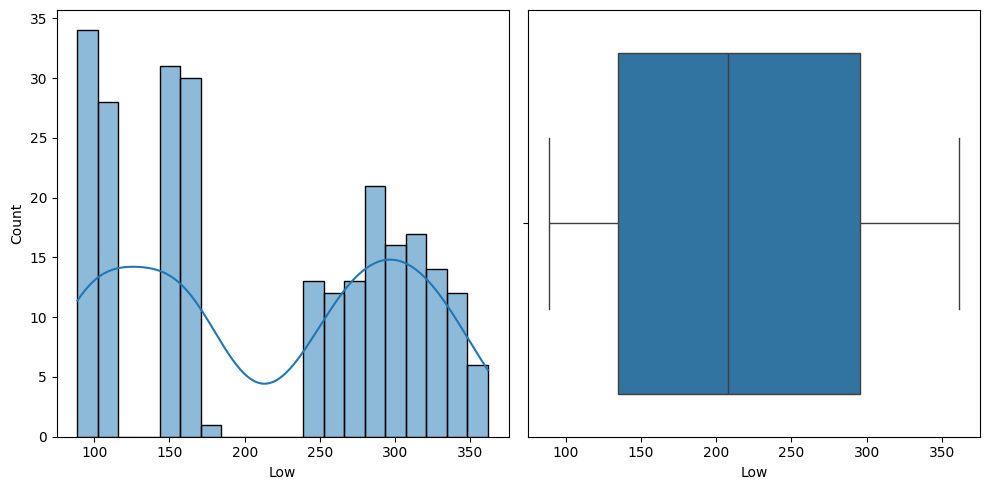

In [ ]:
# create a hist and box plot to see outliers
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(df_final["Low"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["Low"])

plt.tight_layout()
plt.show()

Find outliers from Close column.

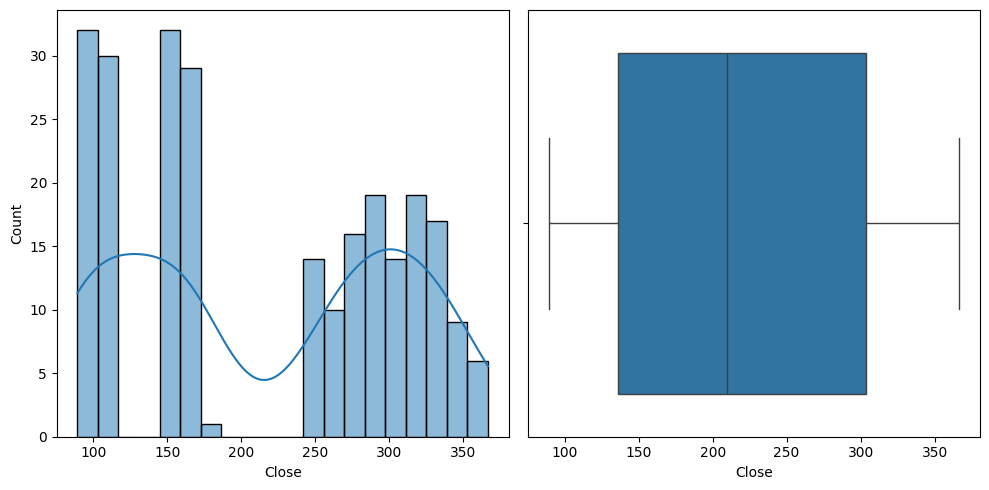

In [ ]:
# create a hist and box plot to see outliers
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(df_final["Close"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["Close"])

plt.tight_layout()
plt.show()

Find outliers from Adj Close column.

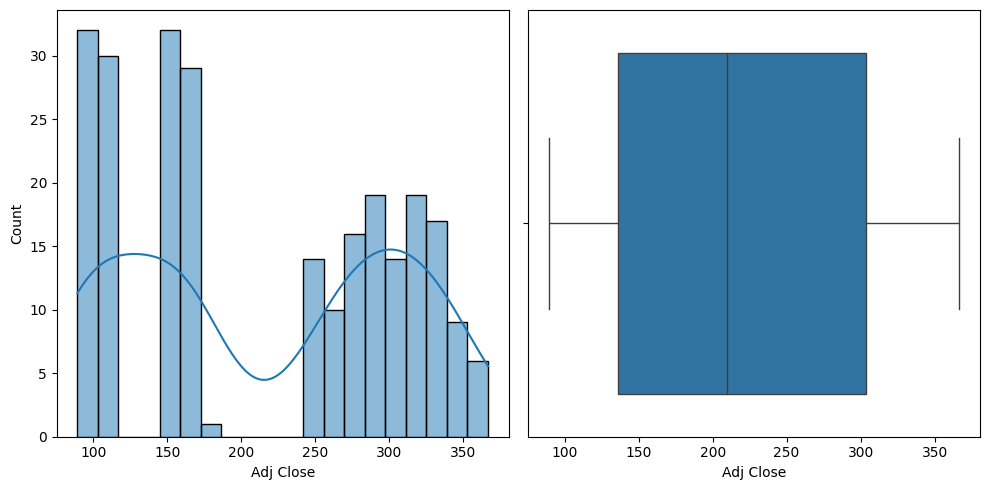

In [ ]:
# create a hist and box plot to see outliers
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(df_final["Adj Close"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["Adj Close"])

plt.tight_layout()
plt.show()

Find outliers from Volume column.

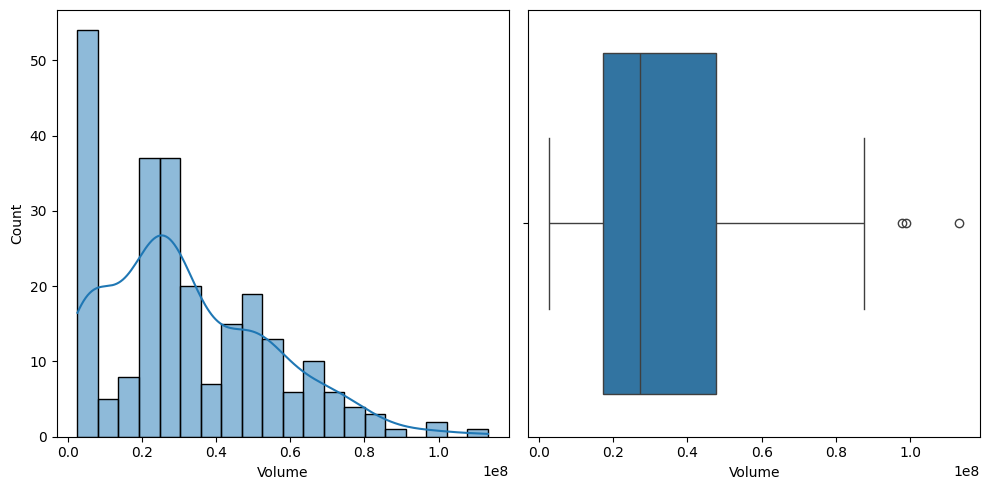

In [ ]:
# create a hist and box plot to see outliers
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(df_final["Volume"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["Volume"])

plt.tight_layout()
plt.show()

Remove outliers using IQR method...

In [ ]:
# Find the upper and lower limit of our data
Q1 = df_final["Volume"].quantile(0.25)
Q3 = df_final["Volume"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

print("Upper Limit:",upper_limit)
print("Lower Limit:",lower_limit)

Upper Limit: 93581612.5
Lower Limit: -28722087.5


In [ ]:
df_final[df_final["Volume"] > upper_limit]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
27,AAPL,2023-03-17,156.080002,156.740005,154.279999,155.000000,155.000000,98944600
61,AAPL,2023-05-05,170.979996,174.300003,170.759995,173.570007,173.570007,113316400
188,GOOG,2023-02-09,100.540001,100.610001,93.860001,95.459999,95.459999,97798600


In [ ]:
df_final[df_final["Volume"] < lower_limit]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume


Triming method...

In [ ]:
# Trim outliers
df_final = df_final[(df_final["Volume"] <= upper_limit) & (df_final["Volume"] >= lower_limit)]

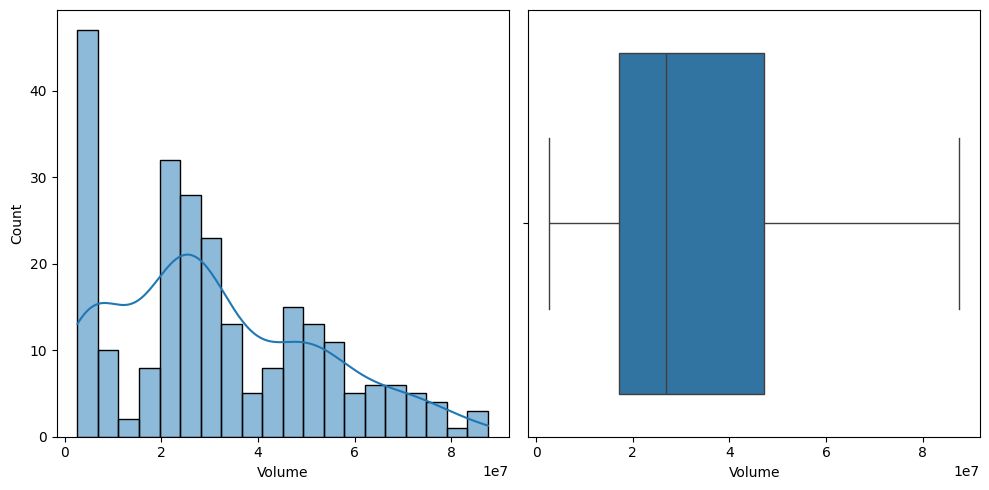

In [ ]:
# create a hist and box plot to see outliers
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
sns.histplot(df_final["Volume"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["Volume"])

plt.tight_layout()
plt.show()

Create Dummie Variables...

In [ ]:
# convert string values into true and false
df_final = pd.get_dummies(df_final, columns = ["Ticker"], drop_first = True)

In [ ]:
# set Dependent variable (y) and Independent variable (x)
y = df_final["Volume"]
x = df_final.drop(["Volume","Date"], axis = 1)
# split data into traning and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

In [ ]:
# Train our model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pridct = model.predict(x_test)

In [ ]:
# Check accuracy (r2_score)
accuracy = r2_score(y_test, y_pridct)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.82


Polynomial Regression...

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
x_train2 = poly.fit_transform(x_train)
x_test2 = poly.fit_transform(x_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(x_train2, y_train)

y_pred = poly_clf.predict(x_test2)


#In sample (training) R^2 will always improve with the number of variables!
print(poly_clf.score(x_train2, y_train))

0.8805660605981074


In [ ]:
#Out off sample (testing) R^2 is our measure of sucess and does improve
print(poly_clf.score(x_test2, y_test))

0.8466405782612099


In [ ]:
# but this improves as the cost of 29 extra variables!
print(x_train.shape)
print(x_train2.shape)

(196, 8)
(196, 37)


In [ ]:
print(x_test.head())

           Open        High         Low       Close   Adj Close  Ticker_GOOG  \
69   264.019989  266.739990  261.899994  262.149994  262.149994        False   
247  105.320000  106.440002  104.738998  106.214996  106.214996         True   
210   93.070000   94.830002   92.779999   94.250000   94.250000         True   
224  102.669998  104.949997  102.379997  104.910004  104.910004         True   
92   273.399994  281.040009  272.179993  272.290009  272.290009        False   

     Ticker_MSFT  Ticker_NFLX  
69          True        False  
247        False        False  
210        False        False  
224        False        False  
92          True        False  


In [ ]:
print(y_test.head())

69     29603600
247    20705300
210    32303900
224    20719900
92     34873300
Name: Volume, dtype: int64


Predict volume...

In [ ]:
row_number = (int(input("Enter a row number:")))

test_input = x_test.iloc[[row_number]]

original_volume = y_test.iloc[row_number]

predicted_volume = model.predict(test_input)[0]

difference = abs(original_volume - predicted_volume)

print(f"TEST DATA PREDICTION CHECK (Row No: {row_number})")
print(f"Original Volume    :  {original_volume:.2f}")
print(f"Predict Volume   :  {predicted_volume:.2f}")
print(f"Difference     :  {difference:.2f}")

Enter a row number:4
TEST DATA PREDICTION CHECK (Row No: 4)
Original Volume    :  34873300.00
Predict Volume   :  34170613.20
Farq (Difference)     :  702686.80
